In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde

In [2]:
gdf = gpd.read_file('data/cleaned/Collision_All_Filtered.geojson')
gdf

,COLDETKEY,LOCATION,SEVERITYCODE,SEVERITYDESC,PERSONCOUNT,PEDCOUNT,PEDCYLCOUNT,VEHCOUNT,INJURIES,SERIOUSINJURIES,...,SDOT_COLCODE,SDOT_COLDESC,UNDERINFL,WEATHER,ROADCOND,LIGHTCOND,YEAR,Day_of_Week,Season,geometry
0,309180,50TH AVE SW AND SW EDMUNDS ST,1,Property Damage Only Collision,4,0,0,3,0,0,...,11,"MOTOR VEHICLE STRUCK MOTOR VEHICLE, FRONT END ...",N,Raining,Wet,Dark - Street Lights On,2018,Monday,Winter,POINT (-122.39629 47.55937)
1,331200,RAINIER AVE S BETWEEN SEWARD PARK AVE S AND 57...,2,Injury Collision,3,0,0,0,1,0,...,11,"MOTOR VEHICLE STRUCK MOTOR VEHICLE, FRONT END ...",Unknown,Unknown,Unknown,Unknown,2020,Sunday,Spring,POINT (-122.26218 47.52019)
2,231900,28TH AVE E AND E MADISON ST,2,Injury Collision,3,0,0,2,2,0,...,11,"MOTOR VEHICLE STRUCK MOTOR VEHICLE, FRONT END ...",N,Overcast,Wet,Daylight,2016,Sunday,Fall,POINT (-122.29619 47.62348)
3,329900,DENNY WAY BETWEEN 7TH NB AVE N AND DEXTER AVE,2,Injury Collision,2,0,0,2,1,0,...,14,"MOTOR VEHICLE STRUCK MOTOR VEHICLE, REAR END",N,Clear,Dry,Dark - Street Lights On,2020,Monday,Winter,POINT (-122.34275 47.61855)
4,193980,16TH AVE S AND S JACKSON ST,1,Property Damage Only Collision,0,0,0,2,0,0,...,11,"MOTOR VEHICLE STRUCK MOTOR VEHICLE, FRONT END ...",N,Clear,Dry,Daylight,2015,Thursday,Spring,POINT (-122.31158 47.59922)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106399,380637,S DAKOTA ST BETWEEN 29TH AVE S AND M L KING JR...,0,Unknown,2,0,0,0,0,0,...,11,"MOTOR VEHICLE STRUCK MOTOR VEHICLE, FRONT END ...",Unknown,Unknown,Unknown,Unknown,2025,Wednesday,Winter,POINT (-122.29737 47.56618)
106400,381416,NW 75TH ST BETWEEN 24TH AVE NW AND 25TH AVE NW,0,Unknown,0,0,0,0,0,0,...,11,"MOTOR VEHICLE STRUCK MOTOR VEHICLE, FRONT END ...",Unknown,Unknown,Unknown,Unknown,2025,Friday,Winter,POINT (-122.38813 47.68316)
106401,379317,2ND AVE AND CHERRY ST,1,Property Damage Only Collision,3,0,0,2,0,0,...,11,"MOTOR VEHICLE STRUCK MOTOR VEHICLE, FRONT END ...",N,Overcast,Wet,Daylight,2024,Friday,Fall,POINT (-122.33317 47.60302)
106402,381437,MINOR AVE BETWEEN HOWELL ST AND STEWART ST,1,Property Damage Only Collision,2,0,0,2,0,0,...,14,"MOTOR VEHICLE STRUCK MOTOR VEHICLE, REAR END",N,Overcast,Dry,Dark - Street Lights On,2025,Tuesday,Spring,POINT (-122.33121 47.61723)


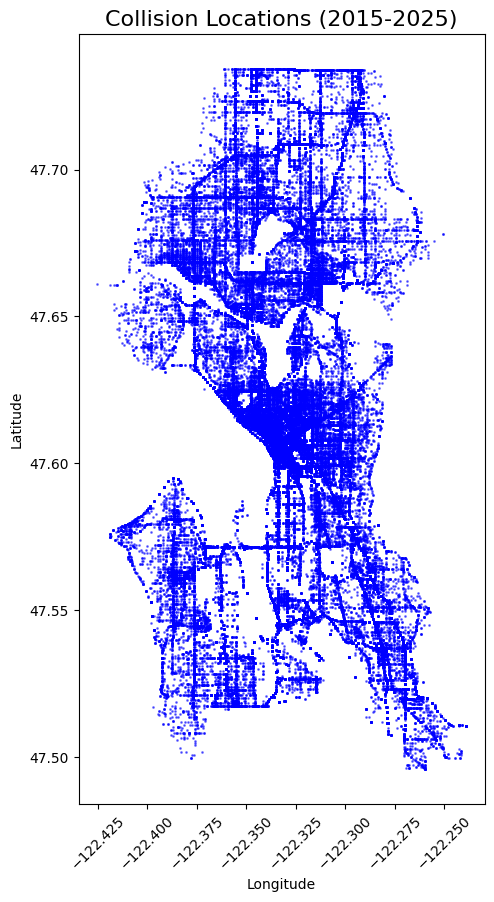

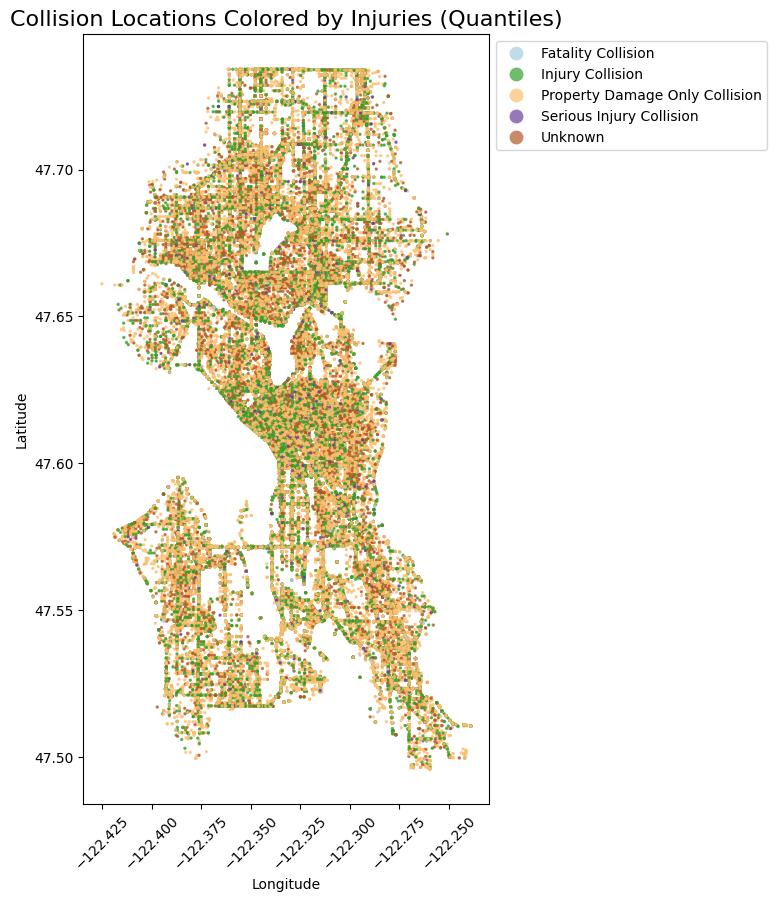

/Users/trentonpham/Code/seattle_collision/.venv/lib/python3.10/site-packages/mapclassify/classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


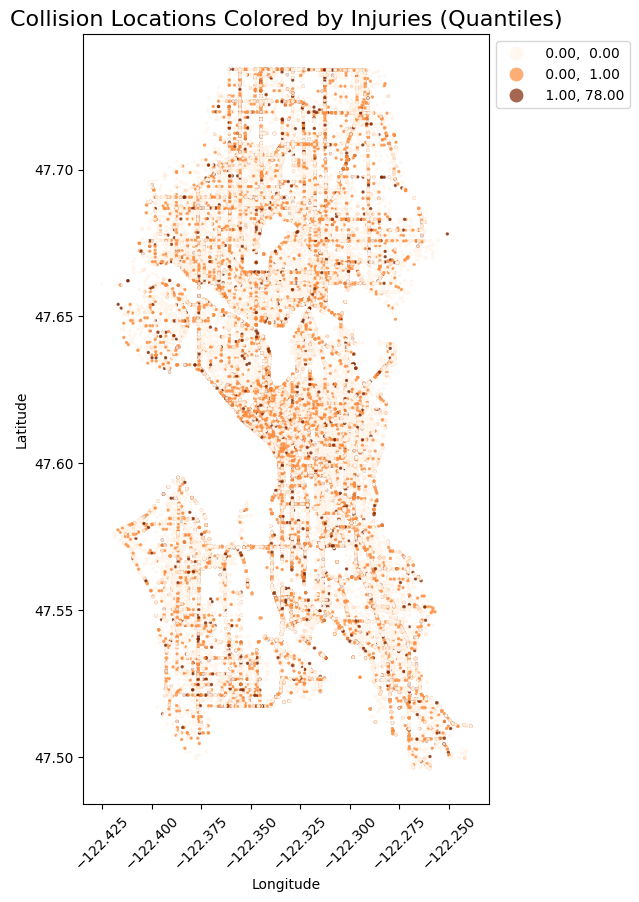

/Users/trentonpham/Code/seattle_collision/.venv/lib/python3.10/site-packages/mapclassify/classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 2.
  self.bins = quantile(y, k=k)


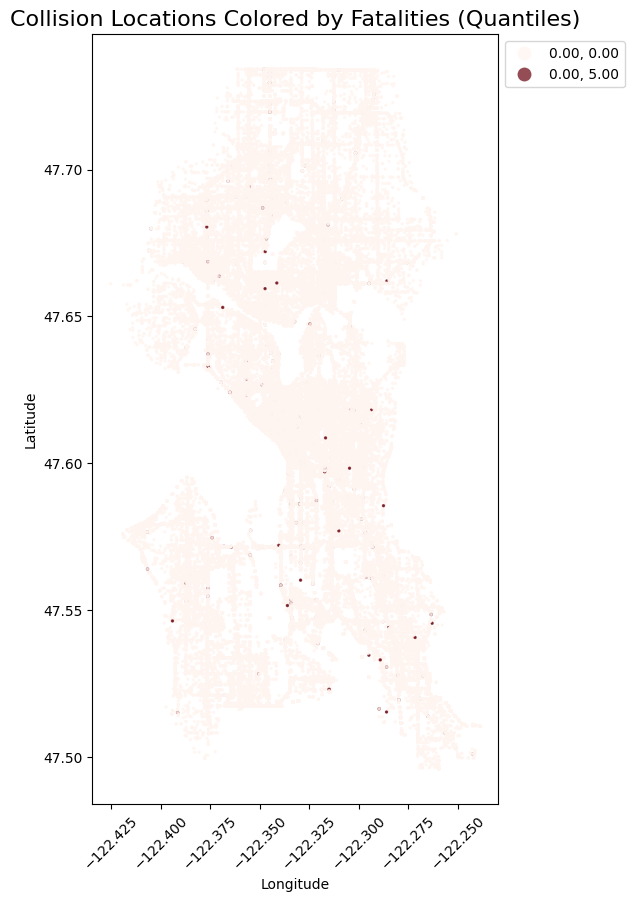

/Users/trentonpham/Code/seattle_collision/.venv/lib/python3.10/site-packages/mapclassify/classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


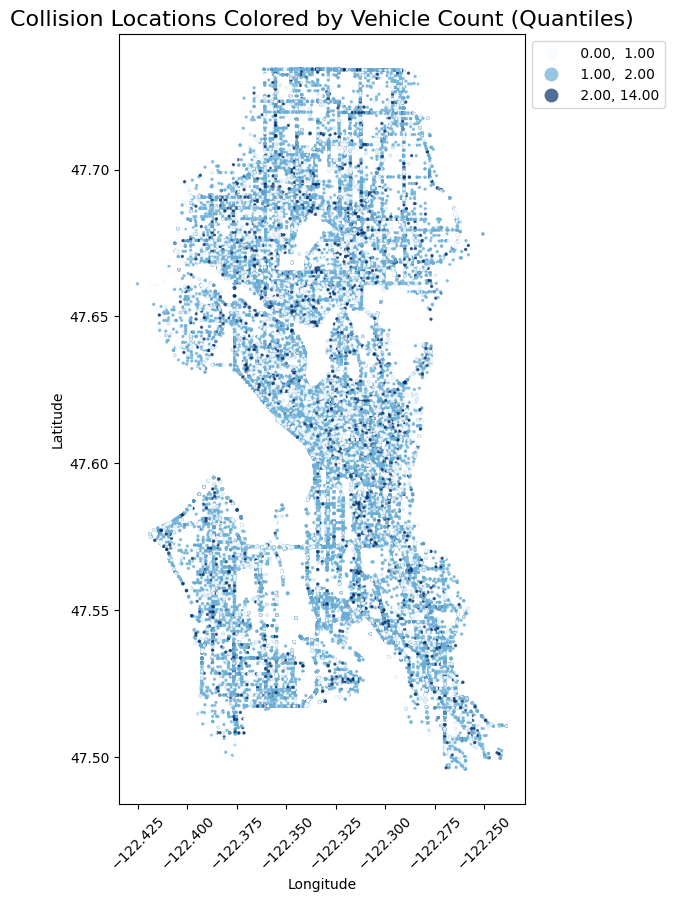

/Users/trentonpham/Code/seattle_collision/.venv/lib/python3.10/site-packages/mapclassify/classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 2.
  self.bins = quantile(y, k=k)


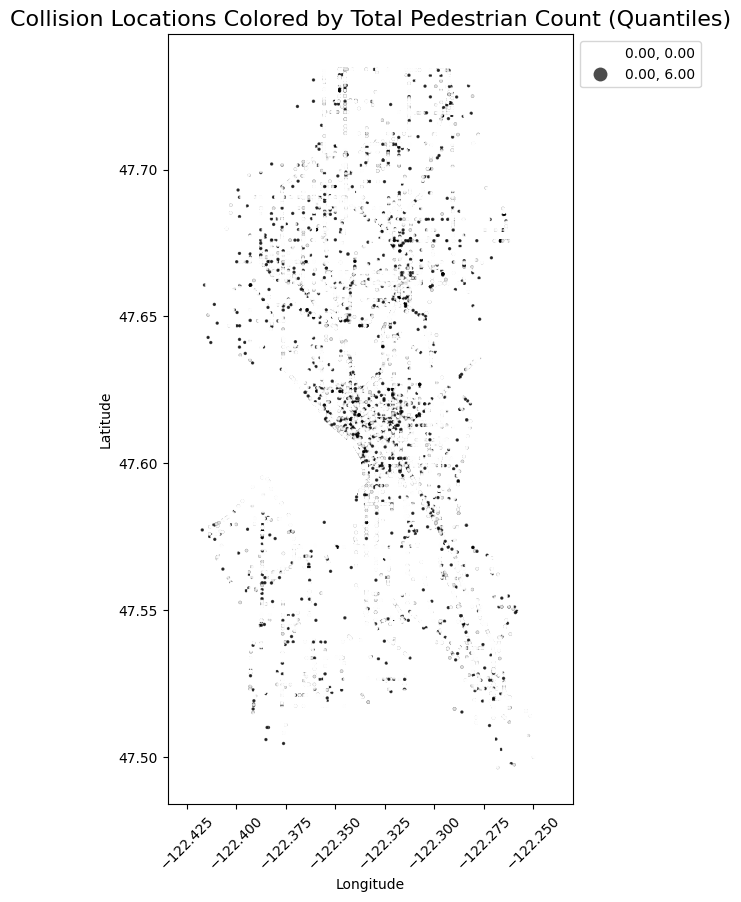

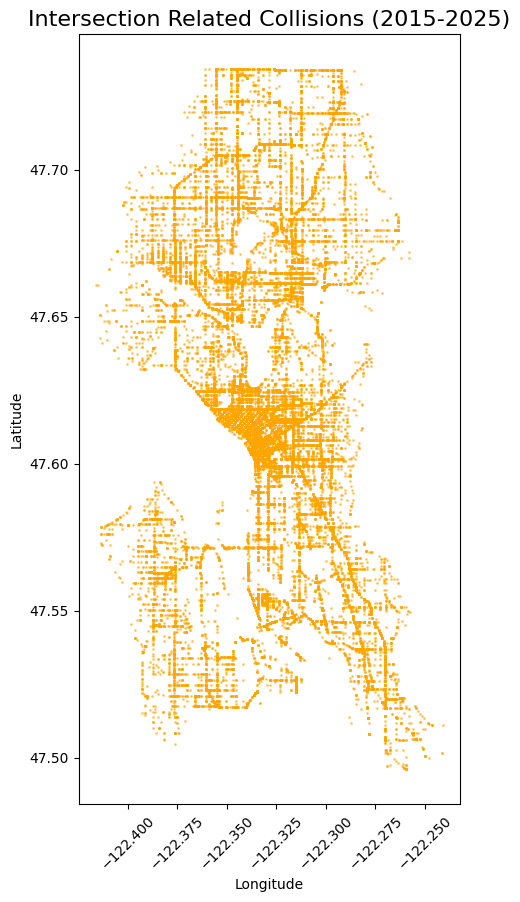

In [3]:
# Plot recent collisions
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
gdf.plot(ax=ax, color='blue', markersize=1, alpha=0.5)
ax.set_title('Collision Locations (2015-2025)', fontsize=16)
ax.set_xlabel('Longitude')
plt.xticks(rotation=45)
ax.set_ylabel('Latitude')
plt.show()

# Plot collisions by collision severity
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
inj_plot = gdf.plot(column='SEVERITYDESC', ax=ax, legend=True, markersize=2, categorical=True, alpha=0.7, cmap='Paired')
ax.set_title('Collision Locations Colored by Injuries (Quantiles)', fontsize=16)
ax.set_xlabel('Longitude')
plt.xticks(rotation=45)
ax.set_ylabel('Latitude')
sns.move_legend(
    inj_plot,
    'upper left',
    bbox_to_anchor=(1,1)
)
plt.show()

# Plot collisions colored by number of injuries
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
inj_plot = gdf.plot(column='INJURIES', ax=ax, legend=True, markersize=2, alpha=0.7, cmap='Oranges', scheme='quantiles')
ax.set_title('Collision Locations Colored by Injuries (Quantiles)', fontsize=16)
ax.set_xlabel('Longitude')
plt.xticks(rotation=45)
ax.set_ylabel('Latitude')
sns.move_legend(
    inj_plot,
    'upper left',
    bbox_to_anchor=(1,1)
)
plt.show()

# Plot collisions colored by number of fatalities
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
fat_plot = gdf.plot(column='FATALITIES', ax=ax, legend=True, markersize=2, alpha=0.7, cmap='Reds', scheme='quantiles')
ax.set_title('Collision Locations Colored by Fatalities (Quantiles)', fontsize=16)
ax.set_xlabel('Longitude')
plt.xticks(rotation=45)
ax.set_ylabel('Latitude')
sns.move_legend(
    fat_plot,
    'upper left',
    bbox_to_anchor=(1,1)
)
plt.show()

# Plot collisions colored by vehicle count
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
veh_plot = gdf.plot(column='VEHCOUNT', ax=ax, legend=True, markersize=2, alpha=0.7, cmap='Blues', scheme='quantiles')
ax.set_title('Collision Locations Colored by Vehicle Count (Quantiles)', fontsize=16)
ax.set_xlabel('Longitude')
plt.xticks(rotation=45)
ax.set_ylabel('Latitude')
sns.move_legend(
    veh_plot,
    'upper left',
    bbox_to_anchor=(1,1)
)
plt.show()

# Plot collisions colored by total pedestrian count
gdf['TOTAL_PED'] = gdf['PEDCOUNT'] + gdf['PEDCYLCOUNT']
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ped_plot = gdf.plot(column='TOTAL_PED', ax=ax, legend=True, markersize=2, alpha=0.7, cmap='Greys', scheme='quantiles')
ax.set_title('Collision Locations Colored by Total Pedestrian Count (Quantiles)', fontsize=16)
ax.set_xlabel('Longitude')
plt.xticks(rotation=45)
ax.set_ylabel('Latitude')
sns.move_legend(
    ped_plot,
    'upper left',
    bbox_to_anchor=(1,1)
)
plt.show()

gdf_int = gdf[(gdf['JUNCTIONTYPE'] == 'At Intersection (intersection related)') | (gdf['JUNCTIONTYPE'] == 'Mid-Block (but intersection related)')]

# Plot intersection-related collisions
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
gdf_int.plot(ax=ax, color='Orange', markersize=1, alpha=0.5)
ax.set_title('Intersection Related Collisions (2015-2025)', fontsize=16)
ax.set_xlabel('Longitude')
plt.xticks(rotation=45)
ax.set_ylabel('Latitude')
plt.show()

In [4]:
gdf = gdf.dropna(subset=['geometry'])
gdf['SEVERITY'] = gdf['INJURIES'] + (gdf['SERIOUSINJURIES'] * 3) + (gdf['FATALITIES'] * 5)
df_pre = gdf[gdf['YEAR'] < 2020]
df_post = gdf[gdf['YEAR'] >= 2020]

pre_2020 = df_pre['SEVERITY']
post_2020 = df_post['SEVERITY']

print(f'{pre_2020.describe()}\n')
print(f'{post_2020.describe()}\n')

stat, p = stats.mannwhitneyu(pre_2020, post_2020, alternative='two-sided')
print(f'Mann-Whitney U: stat={stat:.2f}, p={p:.20f}')
print(f'Pre-2020 mean severity per collision: {pre_2020.mean():.2f}')
print(f'Post-2020 mean severity per collision: {post_2020.mean():.2f}')

count    61828.000000
mean         0.430193
std          1.261624
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        226.000000
Name: SEVERITY, dtype: float64

count    41622.000000
mean         0.502282
std          1.070106
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         29.000000
Name: SEVERITY, dtype: float64

Mann-Whitney U: stat=1256361886.00, p=0.00000000000000102437
Pre-2020 mean severity per collision: 0.43
Post-2020 mean severity per collision: 0.50


/Users/trentonpham/Code/seattle_collision/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


/Users/trentonpham/Code/seattle_collision/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/trentonpham/Code/seattle_collision/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/var/folders/kg/syn5dsfn40l0n2qfhr_8whqh0000gn/T/ipykernel_21215/758351665.py:4: FutureWarning: The default of observed=False is deprecate

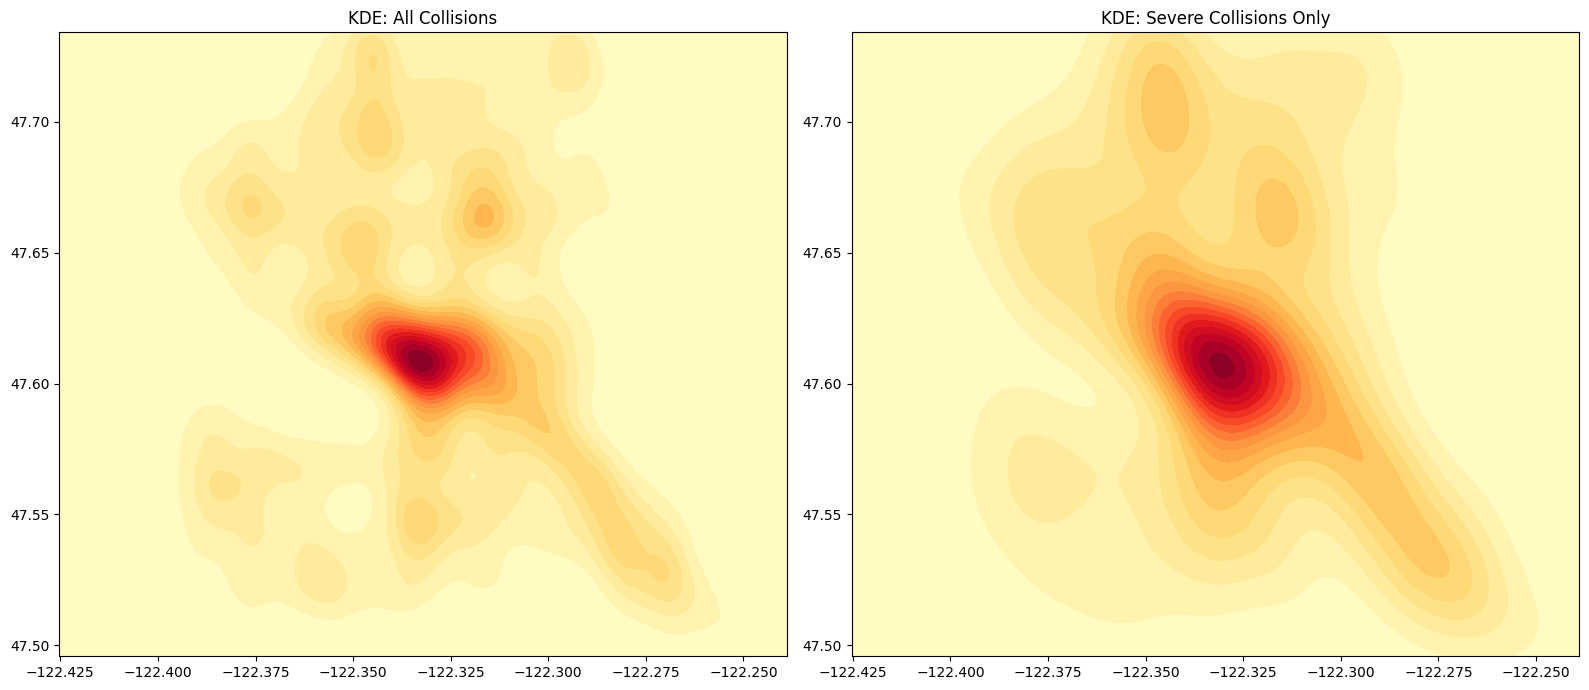

In [5]:
gdf['lat_bin'] = pd.cut(gdf.geometry.y, bins=100)
gdf['lon_bin'] = pd.cut(gdf.geometry.x, bins=100)

grid = gdf.groupby(['lat_bin', 'lon_bin']).agg(
    collision_count=('COLDETKEY', 'count'),
    total_severity=('SEVERITY', 'sum')
).reset_index().dropna()

grid_sorted = grid.sort_values('collision_count')
grid_sorted['cum_collisions'] = grid_sorted['collision_count'].cumsum() / grid_sorted['collision_count'].sum()
grid_sorted['cum_severity'] = grid_sorted['total_severity'].cumsum() / grid_sorted['total_severity'].sum()

coords_all = np.vstack([gdf.geometry.x, gdf.geometry.y])

df_severe = gdf[(gdf['FATALITIES'] > 0) | (gdf['SERIOUSINJURIES'] > 0)]
coords_severe = np.vstack([df_severe.geometry.x, df_severe.geometry.y])

kde_all = gaussian_kde(coords_all)
kde_severe = gaussian_kde(coords_severe)

x = np.linspace(gdf.geometry.x.min(), gdf.geometry.x.max(), 200)
y = np.linspace(gdf.geometry.y.min(), gdf.geometry.y.max(), 200)
xx, yy = np.meshgrid(x, y)
grid_points = np.vstack([xx.ravel(), yy.ravel()])

z_all = kde_all(grid_points).reshape(xx.shape)
z_severe = kde_severe(grid_points).reshape(xx.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 7))
ax[0].contourf(xx, yy, z_all, cmap='YlOrRd', levels=20)
ax[0].set_title('KDE: All Collisions')
ax[1].contourf(xx, yy, z_severe, cmap='YlOrRd', levels=20)
ax[1].set_title('KDE: Severe Collisions Only')
plt.tight_layout()
plt.show()

/var/folders/kg/syn5dsfn40l0n2qfhr_8whqh0000gn/T/ipykernel_21215/1179322748.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


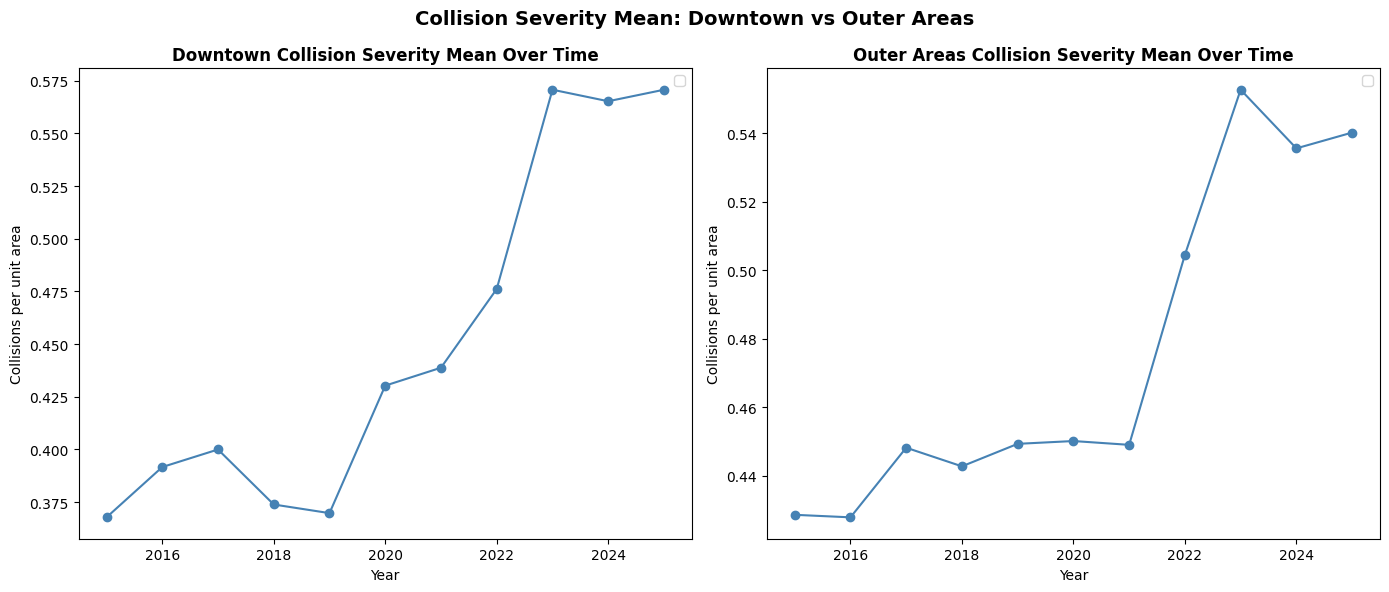

Downtown pre-2020 mean severity:  0.3805
Downtown post-2020 mean severity: 0.5046
Change: +0.1241

Outer pre-2020 mean severity:  0.4387
Outer post-2020 mean severity: 0.5019
Change: +0.0633


In [6]:
downtown_mask = (
    (gdf.geometry.y >= 47.595) & (gdf.geometry.y <= 47.620) &
    (gdf.geometry.x >= -122.345) & (gdf.geometry.x <= -122.320)
    )

df_downtown = gdf[downtown_mask]
df_outer = gdf[~downtown_mask]

# Plot severity over time side by side
dt_sev_year = df_downtown.groupby('YEAR')['SEVERITY'].mean().reset_index()
outer_sev_year = df_outer.groupby('YEAR')['SEVERITY'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, data) in zip(axes, [('Downtown', dt_sev_year), 
                                      ('Outer Areas', outer_sev_year)]):
    ax.plot(data['YEAR'], data['SEVERITY'], marker='o', color='steelblue')
    ax.set_title(f'{label} Collision Severity Mean Over Time', fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Collisions per unit area')
    ax.legend()

plt.suptitle('Collision Severity Mean: Downtown vs Outer Areas', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df_downtown_pre = df_downtown[df_downtown['YEAR'] < 2020]['SEVERITY']
df_downtown_post = df_downtown[df_downtown['YEAR'] >= 2020]['SEVERITY']

print(f"Downtown pre-2020 mean severity:  {df_downtown_pre.mean():.4f}")
print(f"Downtown post-2020 mean severity: {df_downtown_post.mean():.4f}")
print(f"Change: {df_downtown_post.mean() - df_downtown_pre.mean():+.4f}")

# Same for outer
df_outer_pre = df_outer[df_outer['YEAR'] < 2020]['SEVERITY']
df_outer_post = df_outer[df_outer['YEAR'] >= 2020]['SEVERITY']

print(f"\nOuter pre-2020 mean severity:  {df_outer_pre.mean():.4f}")
print(f"Outer post-2020 mean severity: {df_outer_post.mean():.4f}")
print(f"Change: {df_outer_post.mean() - df_outer_pre.mean():+.4f}")

/var/folders/kg/syn5dsfn40l0n2qfhr_8whqh0000gn/T/ipykernel_21215/3728347387.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


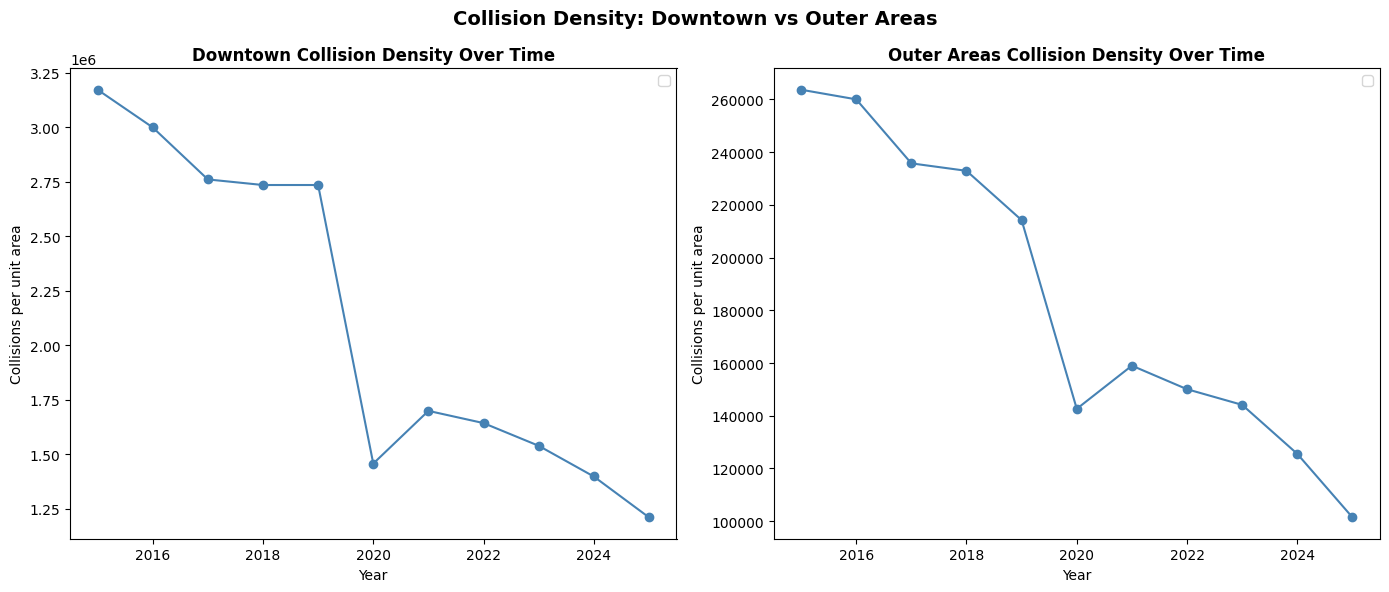

Collision Density Change Post-2020:
Downtown:
  Pre-2020 avg density:  2879680.00
  Post-2020 avg density: 1491466.67
  % Change: -48.2%
Outer:
  Pre-2020 avg density:  241312.52
  Post-2020 avg density: 137144.51
  % Change: -43.2%


In [7]:
# Count collisions per zone per year
downtown_by_year = df_downtown.groupby('YEAR').size().reset_index(name='COUNT')
outer_by_year = df_outer.groupby('YEAR').size().reset_index(name='COUNT')

downtown_area = (47.620 - 47.595) * (122.345 - 122.320)
outer_area = (gdf.geometry.y.max() - gdf.geometry.y.min()) * \
             (gdf.geometry.x.max() - gdf.geometry.x.min()) - downtown_area

downtown_by_year['DENSITY'] = downtown_by_year['COUNT'] / downtown_area
outer_by_year['DENSITY'] = outer_by_year['COUNT'] / outer_area

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, data) in zip(axes, [('Downtown', downtown_by_year), 
                                      ('Outer Areas', outer_by_year)]):
    ax.plot(data['YEAR'], data['DENSITY'], marker='o', color='steelblue')
    ax.set_title(f'{label} Collision Density Over Time', fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Collisions per unit area')
    ax.legend()

plt.suptitle('Collision Density: Downtown vs Outer Areas', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summarize the pre/post change
print("Collision Density Change Post-2020:")
for label, data in [('Downtown', downtown_by_year), ('Outer', outer_by_year)]:
    pre = data[data['YEAR'] < 2020]['DENSITY'].mean()
    post = data[data['YEAR'] >= 2020]['DENSITY'].mean()
    pct_change = ((post - pre) / pre) * 100
    print(f"{label}:")
    print(f"  Pre-2020 avg density:  {pre:.2f}")
    print(f"  Post-2020 avg density: {post:.2f}")
    print(f"  % Change: {pct_change:+.1f}%")

In [8]:
gdf.groupby('JUNCTIONTYPE').size()

JUNCTIONTYPE
At Intersection (but not related to intersection)     1260
At Intersection (intersection related)               36327
Driveway Junction                                     2888
Mid-Block (but intersection related)                  5803
Mid-Block (not related to intersection)              52225
Ramp Junction                                           54
Unknown                                               4893
dtype: int64

In [9]:
gdf

,COLDETKEY,LOCATION,SEVERITYCODE,SEVERITYDESC,PERSONCOUNT,PEDCOUNT,PEDCYLCOUNT,VEHCOUNT,INJURIES,SERIOUSINJURIES,...,ROADCOND,LIGHTCOND,YEAR,Day_of_Week,Season,geometry,TOTAL_PED,SEVERITY,lat_bin,lon_bin
0,309180,50TH AVE SW AND SW EDMUNDS ST,1,Property Damage Only Collision,4,0,0,3,0,0,...,Wet,Dark - Street Lights On,2018,Monday,Winter,POINT (-122.39629 47.55937),0,0,"(47.558, 47.56]","(-122.397, -122.395]"
1,331200,RAINIER AVE S BETWEEN SEWARD PARK AVE S AND 57...,2,Injury Collision,3,0,0,0,1,0,...,Unknown,Unknown,2020,Sunday,Spring,POINT (-122.26218 47.52019),0,1,"(47.52, 47.522]","(-122.263, -122.261]"
2,231900,28TH AVE E AND E MADISON ST,2,Injury Collision,3,0,0,2,2,0,...,Wet,Daylight,2016,Sunday,Fall,POINT (-122.29619 47.62348),0,2,"(47.622, 47.625]","(-122.297, -122.295]"
3,329900,DENNY WAY BETWEEN 7TH NB AVE N AND DEXTER AVE,2,Injury Collision,2,0,0,2,1,0,...,Dry,Dark - Street Lights On,2020,Monday,Winter,POINT (-122.34275 47.61855),0,1,"(47.617, 47.62]","(-122.343, -122.341]"
4,193980,16TH AVE S AND S JACKSON ST,1,Property Damage Only Collision,0,0,0,2,0,0,...,Dry,Daylight,2015,Thursday,Spring,POINT (-122.31158 47.59922),0,0,"(47.598, 47.601]","(-122.312, -122.31]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106399,380637,S DAKOTA ST BETWEEN 29TH AVE S AND M L KING JR...,0,Unknown,2,0,0,0,0,0,...,Unknown,Unknown,2025,Wednesday,Winter,POINT (-122.29737 47.56618),0,0,"(47.565, 47.567]","(-122.299, -122.297]"
106400,381416,NW 75TH ST BETWEEN 24TH AVE NW AND 25TH AVE NW,0,Unknown,0,0,0,0,0,0,...,Unknown,Unknown,2025,Friday,Winter,POINT (-122.38813 47.68316),0,0,"(47.682, 47.684]","(-122.39, -122.388]"
106401,379317,2ND AVE AND CHERRY ST,1,Property Damage Only Collision,3,0,0,2,0,0,...,Wet,Daylight,2024,Friday,Fall,POINT (-122.33317 47.60302),0,0,"(47.601, 47.603]","(-122.334, -122.332]"
106402,381437,MINOR AVE BETWEEN HOWELL ST AND STEWART ST,1,Property Damage Only Collision,2,0,0,2,0,0,...,Dry,Dark - Street Lights On,2025,Tuesday,Spring,POINT (-122.33121 47.61723),0,0,"(47.615, 47.617]","(-122.332, -122.33]"


In [10]:
gdf.to_file('data/processed/Collision_Processed.geojson', driver='GeoJSON')